In [26]:
from langgraph.graph import StateGraph ,START ,END
from typing import TypedDict , Annotated , Literal
from dotenv import load_dotenv
from pydantic import BaseModel , Field
from langchain_groq import ChatGroq
import operator
from langchain_core.messages import SystemMessage , HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [27]:
load_dotenv()

True

In [28]:
llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0
)

In [29]:
class JokeState(TypedDict):

    topic : str 
    joke : str 
    explanation : str 
    

In [31]:
def generate_joke(state: JokeState):

    prompt = f"Generate a joke on the topic {state['topic']}"
    response = llm.invoke(prompt).content

    return {"joke": response}

In [32]:
def generate_explanation(state : JokeState):

    prompt = f'Write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation' : response}

In [33]:
checkpointer = InMemorySaver()
graph = StateGraph(JokeState)

# Add Nodes
graph.add_node('generate_joke' , generate_joke)
graph.add_node('generate_explanation' , generate_explanation)

# Add edges
graph.add_edge(START , 'generate_joke')
graph.add_edge('generate_joke' , 'generate_explanation')
graph.add_edge('generate_explanation' , END)

workflow = graph.compile(checkpointer=checkpointer)

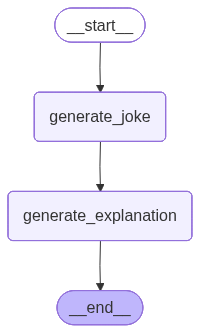

In [34]:
workflow

In [40]:
config1 = {'configurable' : {'thread_id' : '1'}}
workflow.invoke({'topic' : 'pizza'} , config=config1)

{'topic': 'pizza',
 'joke': '<think>\nOkay, I need to come up with a joke about pizza. Let me think... Pizza is a popular topic, so there are lots of angles. Maybe play on toppings? Or the shape? Or something related to eating it?\n\nHmm, common pizza toppings are pepperoni, mushrooms, olives... Maybe a pun with those? Or maybe something about the pizza itself being a "pie" but not a dessert. Wait, there\'s a classic joke about why the pizza is round but it\'s called a pie. Maybe build on that.\n\nOr maybe personify the pizza. Like why did the pizza go to the doctor? Because it was feeling cheesy? Not sure. Or maybe a play on words with "slice of life" and "slice of pizza."\n\nWait, here\'s an idea: Why don\'t pizzas ever get cold? Because they always wear a crust jacket. Hmm, crust jacket... Maybe not the best. Or maybe something with ovens?\n\nAnother angle: Delivery. Like why did the pizza get a ticket? Because it was stopped for not having a license (no license to deliver? Maybe no

In [41]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': '<think>\nOkay, I need to come up with a joke about pizza. Let me think... Pizza is a popular topic, so there are lots of angles. Maybe play on toppings? Or the shape? Or something related to eating it?\n\nHmm, common pizza toppings are pepperoni, mushrooms, olives... Maybe a pun with those? Or maybe something about the pizza itself being a "pie" but not a dessert. Wait, there\'s a classic joke about why the pizza is round but it\'s called a pie. Maybe build on that.\n\nOr maybe personify the pizza. Like why did the pizza go to the doctor? Because it was feeling cheesy? Not sure. Or maybe a play on words with "slice of life" and "slice of pizza."\n\nWait, here\'s an idea: Why don\'t pizzas ever get cold? Because they always wear a crust jacket. Hmm, crust jacket... Maybe not the best. Or maybe something with ovens?\n\nAnother angle: Delivery. Like why did the pizza get a ticket? Because it was stopped for not having a license (no license 

In [42]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': '<think>\nOkay, I need to come up with a joke about pizza. Let me think... Pizza is a popular topic, so there are lots of angles. Maybe play on toppings? Or the shape? Or something related to eating it?\n\nHmm, common pizza toppings are pepperoni, mushrooms, olives... Maybe a pun with those? Or maybe something about the pizza itself being a "pie" but not a dessert. Wait, there\'s a classic joke about why the pizza is round but it\'s called a pie. Maybe build on that.\n\nOr maybe personify the pizza. Like why did the pizza go to the doctor? Because it was feeling cheesy? Not sure. Or maybe a play on words with "slice of life" and "slice of pizza."\n\nWait, here\'s an idea: Why don\'t pizzas ever get cold? Because they always wear a crust jacket. Hmm, crust jacket... Maybe not the best. Or maybe something with ovens?\n\nAnother angle: Delivery. Like why did the pizza get a ticket? Because it was stopped for not having a license (no license